In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


 10 MW BESS ANCILLARY SERVICES (FCR/aFRR) CO-OPTIMIZATION BENCHMARK
1. Pure Day-Ahead Arbitrage Revenue:   €45,213.43
2. Dedicated Pure FCR Reserve Revenue: €119,858.70
3. Co-Optimized Multi-Market Revenue:  €130,503.36
---------------------------------------------------------------------------
PnL Uplift vs Pure DA Arbitrage:       +€85,289.93 (+188.6%)
PnL Uplift vs Pure FCR Reservation:    +€10,644.66 (+8.9%)


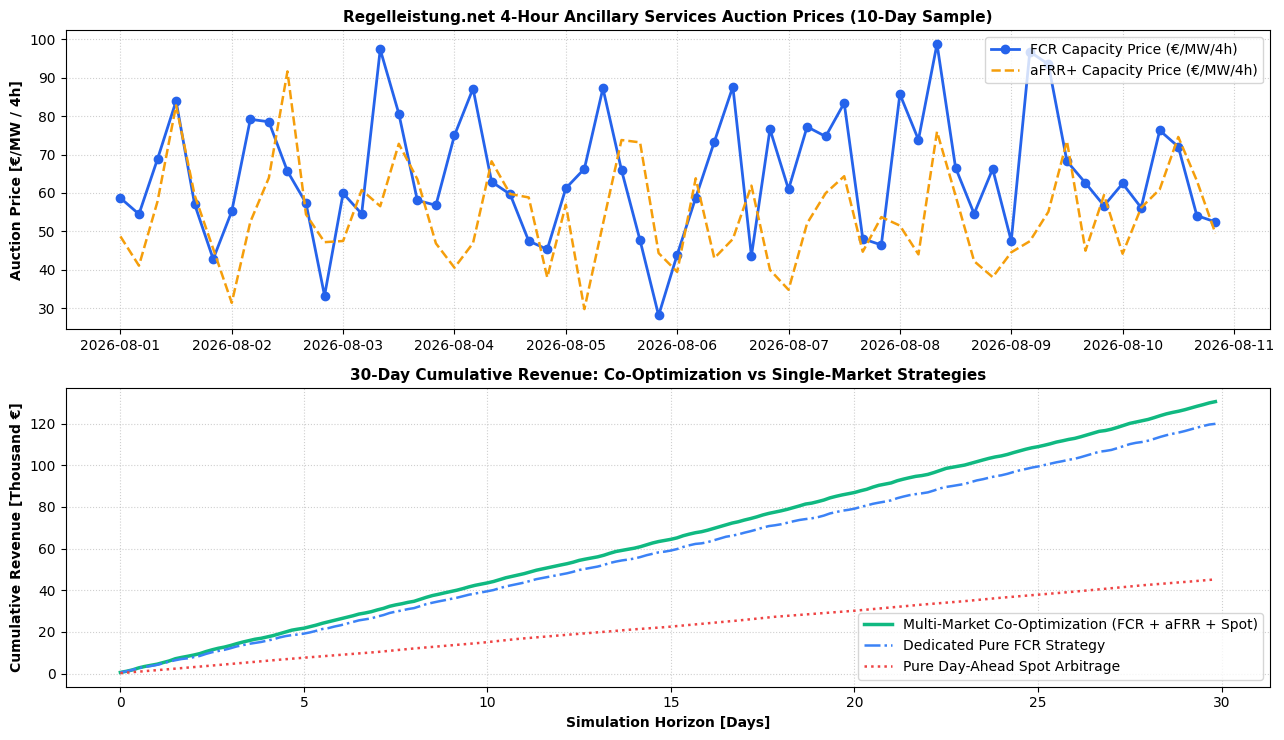

Data exported successfully as 'fcr_afrr_bess_simulation_results_2026.csv'


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================================
# 1. 10 MW BESS SPECIFICATIONS & MARKET ENVIRONMENT (GERMANY)
# ==========================================================
np.random.seed(42)
N_DAYS = 30  # 30-day simulation (180 four-hour auction blocks)
HOURS = N_DAYS * 24
N_BLOCKS = N_DAYS * 6

timestamps_4h = pd.date_range(
    start="2026-08-01 00:00:00", periods=N_BLOCKS, freq="4h"
)
timestamps_hourly = pd.date_range(
    start="2026-08-01 00:00:00", periods=HOURS, freq="h"
)
hour_of_day = timestamps_hourly.hour.to_numpy()

# A. Hourly Day-Ahead Spot Wholesale Prices (€/MWh)
da_hourly = (
    45.0
    + 35.0 * np.sin((hour_of_day - 4) * np.pi / 12)
    + np.random.normal(0, 10, HOURS)
)
da_hourly = np.round(np.clip(da_hourly, -25.0, 220.0), 2)

# B. 4-Hour Auction Clearing Prices on Regelleistung.net (€/MW / 4h block)
block_hours = timestamps_4h.hour.to_numpy()
fcr_base = (
    65.0
    + 20.0 * np.sin((block_hours - 2) * np.pi / 12)
    + np.random.normal(0, 12, N_BLOCKS)
)
fcr_clearing_price = np.round(np.clip(fcr_base, 25.0, 140.0), 2)

afrr_pos_capacity = (
    45.0
    + 25.0 * np.maximum(0, np.sin((block_hours - 6) * np.pi / 12))
    + np.random.normal(0, 10, N_BLOCKS)
)
afrr_pos_capacity = np.round(np.clip(afrr_pos_capacity, 15.0, 110.0), 2)

# ==========================================================
# 2. STRATEGY BENCHMARKING (10 MW / 20 MWh BESS)
# ==========================================================
# Strategy 1: Pure Day-Ahead Spot Arbitrage
daily_arbitrage_rev = []
for d in range(N_DAYS):
  day_prices = da_hourly[d * 24 : (d + 1) * 24]
  spread = np.sort(day_prices)[-2:].mean() - np.sort(day_prices)[:2].mean()
  rev_d = 10.0 * 2.0 * 0.88 * max(0, spread)  # 10 MW, 2h, 88% RTE
  daily_arbitrage_rev.append(rev_d)
total_rev_arbitrage = sum(daily_arbitrage_rev)

# Strategy 2: Dedicated Pure FCR Strategy
total_rev_pure_fcr = np.sum(10.0 * fcr_clearing_price)

# Strategy 3: Multi-Market Dynamic Co-Optimization (FCR vs aFRR vs Arbitrage)
coopt_block_rev = []
allocated_market = []

for b in range(N_BLOCKS):
  fcr_p = fcr_clearing_price[b]
  afrr_p = afrr_pos_capacity[b]

  block_da_prices = da_hourly[b * 4 : (b + 1) * 4]
  block_spread = block_da_prices.max() - block_da_prices.min()
  da_pot_rev_per_mw = block_spread * 0.88 * 1.5

  fcr_rev = 10.0 * fcr_p
  da_rev = 10.0 * da_pot_rev_per_mw
  afrr_rev = 10.0 * afrr_p * 1.15  # Includes expected energy activation margin

  best_rev = max(fcr_rev, da_rev, afrr_rev)
  coopt_block_rev.append(best_rev)

  if best_rev == fcr_rev:
    allocated_market.append('FCR')
  elif best_rev == da_rev:
    allocated_market.append('DA_Arbitrage')
  else:
    allocated_market.append('aFRR')

total_rev_coopt = sum(coopt_block_rev)
uplift_vs_arb = total_rev_coopt - total_rev_arbitrage
uplift_vs_fcr = total_rev_coopt - total_rev_pure_fcr

print('=' * 75)
print(' 10 MW BESS ANCILLARY SERVICES (FCR/aFRR) CO-OPTIMIZATION BENCHMARK')
print('=' * 75)
print(f'1. Pure Day-Ahead Arbitrage Revenue:   €{total_rev_arbitrage:,.2f}')
print(f'2. Dedicated Pure FCR Reserve Revenue: €{total_rev_pure_fcr:,.2f}')
print(f'3. Co-Optimized Multi-Market Revenue:  €{total_rev_coopt:,.2f}')
print('-' * 75)
print(
    f'PnL Uplift vs Pure DA Arbitrage:       +€{uplift_vs_arb:,.2f} (+'
    f'{(uplift_vs_arb/total_rev_arbitrage)*100:.1f}%)'
)
print(
    f'PnL Uplift vs Pure FCR Reservation:    +€{uplift_vs_fcr:,.2f} (+'
    f'{(uplift_vs_fcr/total_rev_pure_fcr)*100:.1f}%)'
)
print('=' * 75)

# ==========================================================
# 3. VISUALIZATIONS & EXPORT
# ==========================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7.5))

# Plot 1: 4-Hour Auction Clearing Prices
sample_blocks = 60
ax1.plot(
    timestamps_4h[:sample_blocks],
    fcr_clearing_price[:sample_blocks],
    color='#2563EB',
    lw=2.0,
    marker='o',
    label='FCR Capacity Price (€/MW/4h)',
)
ax1.plot(
    timestamps_4h[:sample_blocks],
    afrr_pos_capacity[:sample_blocks],
    color='#F59E0B',
    lw=1.8,
    linestyle='--',
    label='aFRR+ Capacity Price (€/MW/4h)',
)
ax1.set_ylabel('Auction Price [€/MW / 4h]', fontweight='bold')
ax1.set_title(
    'Regelleistung.net 4-Hour Ancillary Services Auction Prices (10-Day Sample)',
    fontweight='bold',
    fontsize=11,
)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right')

# Plot 2: Cumulative Revenue Trajectory
days_x = np.arange(N_BLOCKS) / 6.0
cum_arb = (
    np.cumsum(np.repeat(np.array(daily_arbitrage_rev) / 6.0, 6)) / 1000.0
)
cum_fcr = np.cumsum(10.0 * fcr_clearing_price) / 1000.0
cum_coopt = np.cumsum(coopt_block_rev) / 1000.0

ax2.plot(
    days_x,
    cum_coopt,
    color='#10B981',
    lw=2.5,
    label='Multi-Market Co-Optimization (FCR + aFRR + Spot)',
)
ax2.plot(
    days_x,
    cum_fcr,
    color='#3B82F6',
    lw=1.8,
    linestyle='-.',
    label='Dedicated Pure FCR Strategy',
)
ax2.plot(
    days_x,
    cum_arb,
    color='#EF4444',
    lw=1.8,
    linestyle=':',
    label='Pure Day-Ahead Spot Arbitrage',
)
ax2.set_xlabel('Simulation Horizon [Days]', fontweight='bold')
ax2.set_ylabel('Cumulative Revenue [Thousand €]', fontweight='bold')
ax2.set_title(
    '30-Day Cumulative Revenue: Co-Optimization vs Single-Market Strategies',
    fontweight='bold',
    fontsize=11,
)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.savefig('fcr_afrr_ancillary_services_optimization.png', dpi=300)
plt.show()

# Export Data
df_export_ancillary = pd.DataFrame({
    'timestamp_4h': timestamps_4h,
    'fcr_price_eur_mw_4h': fcr_clearing_price,
    'afrr_pos_price_eur_mw_4h': afrr_pos_capacity,
    'allocated_market': allocated_market,
    'coopt_rev_eur': coopt_block_rev,
})
df_export_ancillary.to_csv(
    'fcr_afrr_bess_simulation_results_2026.csv', index=False
)
print("Data exported successfully as 'fcr_afrr_bess_simulation_results_2026.csv'")